<a href="https://colab.research.google.com/github/minisemin/fluffy-sniffle/blob/main/Copy_of_programming_from_zero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROGRAMMING FROM ZERO: AI-ASSISTED PROGRAMMING FOR RESEARCH

*Joseph L Hellerstein* (jlheller@uw.edu)

eScience Institute

February 23, 2026

# Introduction

This notebook provides an introduction to AI-Assisted programming for researchers. A limited experience with programming is helpful, but not required.
The notebook describes a workflow for an analysis that is understandable for a broad community that is used as an aid for pedagogy.

The key skill being taught is **LLM collaboration**. An LLM (Large Language Model) is a program that interacts with the user through natural (human) language as opposed to computer languages like Python or Java. Common LLMs are ChatGPT, Claude, and Gemini. Although the LLM can be surprisingly good at responding to requests and questions, *LLMs do not understand human language as humans do*. As a result, LLMs can misinterpret a request, and even generate nonsensical responses (often called halluciations).

This notebook develops your skills with LLM collaborations through the following scenario:
* You are a first year graduate student in sociology or political science interested in quantitative techniques.
* Your advisor has asked you to analyze changes in partisanship over time based on data from the American National Election Survey (ANES) culmulative dataset.
* As a reference for this analysis, your advisor suggested that you read "'I disrepsectfully agree.' The Differential Effects of  Partisan Sorting on Behavioral and Issue Polarization", L Mason, 2014.
* Previously, you have done some computations in spreadsheets, but you have no programming experience.
* To help you get started, your advisor has provided a copy of the data on a [webpage](https://github.com/joseph-hellerstein/programming_from_zero/blob/main/data/anes_timeseries_cdf_csv_20260205_bottom.csv).

## Set up

**Create a copy of this notebook and open in Colab**
1. Download the notebook. ``File>Download>Download.ipynb``
2. Browse to your Google Drive. ``https://drive.google.com/drive/home``
3. Upload the notebook. ``+New>File upload>"Your download folder">programming_from_zero.ipynb``
4. Double-click ``programming_from_zero.ipynb``

## Evolution of Human-Computer Interactions

Before diving into the above scenario, we provide some historical context for programming computers.

<img src="https://raw.githubusercontent.com/joseph-hellerstein/programming_from_zero/main/docs/images/programming_history.png"
         alt="Types of feature extractiom."
         width="5000">

Theme: Creating programs that can be *read* by humans.

Shortcoming: Special training is required to *write* programs.

With LLMs, we can interact with computers using natural language. This makes it possible for many more people to do computational work.
Below is a simple example.


<img src="https://raw.githubusercontent.com/joseph-hellerstein/programming_from_zero/main/docs/images/ai_assisted_programming.png"
         alt="Types of feature extractiom."
         width="5000">

## Learning Objectives

1. Students will be able to write prompts to list the descriptions and scales of variables used in the analysis.
1. Students will be able to compose LLM prompts for:
    1. creating a pandas DataFrame containing variables of interest with descriptive column names for the variables;
    1. constructing univariate statistics for categorical data;
    1. constructing heatmaps of the US (choropleths).
1. Students can find known results to assess the correctness of the results of code execution.
1.  Students will be able to construct notebooks that run correctly when shared with others.


# Python for Data Analysis

Although we want the LLM to do most of the detailed work of Python programming, we need to know a bit about Python to judge whether the LLM has done what we intended. This is much like being a supervisor on a factor floor. We have to know about the manufacturing process and the machines our workers are using in order to guide employees and make the factory efficient.

## What is Python

* Python is a procedural computer language intended to be human readable (but not necessarily human writeable).

* Python has a core, and it has many add-ons called libraries. To include a library in your program, you use an ``import`` statement. Libraries are used to read data, do statistical analysis and do plotting.

* All elements of Python are objects. Objects may contain both data and executable code. The components of an object are called attributes and are accessed using the dot (".") operator. Names in Python are case sensitive.

## Simple Python

In [ ]:
# Setting values and added them
var1 = 1
var2 = 2
print(var1 + var2)

3


In [ ]:
# Check if a string has a list of words

# Create a string by using double or single quotes
a_string = "The quick brown fox jumps over the lazy dog"

# Create a list of words to find
words = ["dog", "fox", "bear"]

# Search for each word in the string by using 'for' to iterate and 'if' to test
for word in words:
    if word in a_string:
        print(f"Found {word}!")


Found dog!
Found fox!


Functions provide a way to create your own library of useful data and code.

A function using specified using ``def``. You provide a function name, its inputs (arguments),
and use a ``return`` statement to return results.

In [ ]:
# You can make code reusable by defining a function
def searchString(search_string:str, search_words:list)->list:
    results = []
    for word in search_words:
        if word in search_string:
            results.append(word)
    return results

# Run the function
a_string = "The quick brown fox jumps over the lazy dog"
words = ["dog", "fox", "bear"]
searchString(a_string, words)

['dog', 'fox']

## DataFrames

A DataFrame is a python representation of a table.

* A table has columns of the same length (and type). Columns have names.
* A table has rows, each of which contains a value for all columns.
* You can select subsets of rows and columns based on the values in the table.

In [ ]:
# An example
import pandas as pd

household_df = pd.DataFrame({
    'family': ['adams', 'johnson', 'smith'],
    'pets': ['yes', 'no', 'maybe'],
    'num_children': [2, 0, 10],
    'num_occupant': [4, 2, 11],
}
)
household_df

,family,pets,num_children,num_occupant
0,adams,yes,2,4
1,johnson,no,0,2
2,smith,maybe,10,11


In [ ]:
# Names of the families
household_df['family']

,family
0,adams
1,johnson
2,smith


In [ ]:
# Can use a variable instead of a string
family_column = 'family'
household_df[family_column]

,family
0,adams
1,johnson
2,smith


In [ ]:
# Can do operations on columns (and rows)

In [ ]:
# How many adjults are there in the households? Add an 'num_adult' column
household_df['num_adult'] = household_df['num_occupant'] - household_df['num_children']
household_df

,family,pets,num_children,num_occupant,num_adult
0,adams,yes,2,4,2
1,johnson,no,0,2,2
2,smith,maybe,10,11,1


In [ ]:
# Select the families who have children
selector = household_df['num_children'] > 0
household_df[selector]

,family,pets,num_children,num_occupant,num_adult
0,adams,yes,2,4,2
2,smith,maybe,10,11,1


## Python libraries used in this notebook

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML
import markdown
try:
    import folium
except:
    !pip install folium
    import folium
try:
    import us
except:
    !pip install us
    import us

# Getting the data

We begin by writing python to read data in a comma-separated-variable (CSV) file, and we'll use Gemini to help us.

##***SKILL: Access the Gemini LLM by clicking on the "sparkle" (white "cross" in the blue ball) at the bottom of the notebook.***

##***SKILL: Isolate LLM interactions by headings so that they are easy to identify, copy, and delete.***

## Interactions

**Prompt: Get the data**

Create python code that reads the CSV in the above Introduction URL into a dataframe called ANES_DF. Please ignore other parts of the notebook.

## Result

In [ ]:
# @title
import pandas as pd

# The raw URL for the CSV file, as referenced in the text cell above.
URL = 'https://raw.githubusercontent.com/joseph-hellerstein/programming_from_zero/main/data/anes_timeseries_cdf_csv_20260205_bottom.csv'

ANES_DF = pd.read_csv(URL)
display(ANES_DF.head())

/tmp/ipython-input-218566924.py:7: DtypeWarning: Columns (4,5,6,7,8,9,13,14,17,18,19,21,22,23,24,25,26,27,28,29,30,31,32,33,38,42,43,45,47,48,49,51,53,60,62,63,65,66,67,68,69,70,72,73,74,76,77,79,80,81,82,83,84,89,90,91,95,96,97,98,99,100,101,104,105,106,107,108,109,113,116,117,118,120,121,122,126,127,128,129,130,131,132,133,135,136,137,138,139,140,141,142,143,144,145,146,147,150,151,152,154,157,158,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,233,254,275,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,318,323,328,330,331,332,333,334,335,336,337,338,339,340,361,382,403,424,425,426,427,428,430,431,433,434,435,436,437,438,439,447,448,449,450,451,452,453,454,458,459,460,462,463,467,468,469,470,473,474,475,476,478,484,485,489,490,491,498,499,500,504,505,506,507,510,511,513,514,515,524,525,526,5

,Version,VCF0004,VCF0006,VCF0006a,VCF0009x,VCF0010x,VCF0011x,VCF0009y,VCF0010y,VCF0011y,...,VCF9272,VCF9273,VCF9274,VCF9275,VCF9277,VCF9278,VCF9279,VCF9280,VCF9281,VCF9282
0,ANES_CDF_VERSION:2026-Feb-5,1986,563,19860563,1,1,1,1,1,1,...,,,,,-9,-9,,,,
1,ANES_CDF_VERSION:2026-Feb-5,1986,564,19860564,1,1,1,1,1,1,...,,,,,-9,-9,,,,
2,ANES_CDF_VERSION:2026-Feb-5,1986,565,19860565,1,1,1,1,1,1,...,,,,,-9,-9,,,,
3,ANES_CDF_VERSION:2026-Feb-5,1986,566,19860566,1,1,1,1,1,1,...,,,,,1,2,,,,
4,ANES_CDF_VERSION:2026-Feb-5,1986,567,19860567,1,1,1,1,1,1,...,,,,,3,-9,,,,


In [ ]:
def is_prime(number: int) -> bool:
    """
    Checks if a given integer is a prime number.

    A prime number is a natural number greater than 1 that has no positive divisors
    other than 1 and itself.

    Args:
        number (int): The integer to be checked.

    Returns:
        bool: True if the number is prime, False otherwise.
    """
    if number <= 1:
        return False
    if number <= 3:
        return True
    if number % 2 == 0 or number % 3 == 0:
        return False
    i = 5
    while i * i <= number:
        if number % i == 0 or number % (i + 2) == 0:
            return False
        i += 6
    return True

# Example usage:
print(f"Is 7 prime? {is_prime(7)}")
print(f"Is 10 prime? {is_prime(10)}")
print(f"Is 2 prime? {is_prime(2)}")
print(f"Is 1 prime? {is_prime(1)}")
print(f"Is 29 prime? {is_prime(29)}")
print(f"Is 97 prime? {is_prime(97)}")


In [ ]:
import pandas as pd

URL = 'https://raw.githubusercontent.com/joseph-hellerstein/programming_from_zero/main/data/anes_timeseries_cdf_csv_20260205_bottom.csv'
ANES_DF = pd.read_csv(URL)
display(ANES_DF.head())

/tmp/ipython-input-1425192703.py:4: DtypeWarning: Columns (4,5,6,7,8,9,13,14,17,18,19,21,22,23,24,25,26,27,28,29,30,31,32,33,38,42,43,45,47,48,49,51,53,60,62,63,65,66,67,68,69,70,72,73,74,76,77,79,80,81,82,83,84,89,90,91,95,96,97,98,99,100,101,104,105,106,107,108,109,113,116,117,118,120,121,122,126,127,128,129,130,131,132,133,135,136,137,138,139,140,141,142,143,144,145,146,147,150,151,152,154,157,158,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,233,254,275,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,318,323,328,330,331,332,333,334,335,336,337,338,339,340,361,382,403,424,425,426,427,428,430,431,433,434,435,436,437,438,439,447,448,449,450,451,452,453,454,458,459,460,462,463,467,468,469,470,473,474,475,476,478,484,485,489,490,491,498,499,500,504,505,506,507,510,511,513,514,515,524,525,526,

,Version,VCF0004,VCF0006,VCF0006a,VCF0009x,VCF0010x,VCF0011x,VCF0009y,VCF0010y,VCF0011y,...,VCF9272,VCF9273,VCF9274,VCF9275,VCF9277,VCF9278,VCF9279,VCF9280,VCF9281,VCF9282
0,ANES_CDF_VERSION:2026-Feb-5,1986,563,19860563,1,1,1,1,1,1,...,,,,,-9,-9,,,,
1,ANES_CDF_VERSION:2026-Feb-5,1986,564,19860564,1,1,1,1,1,1,...,,,,,-9,-9,,,,
2,ANES_CDF_VERSION:2026-Feb-5,1986,565,19860565,1,1,1,1,1,1,...,,,,,-9,-9,,,,
3,ANES_CDF_VERSION:2026-Feb-5,1986,566,19860566,1,1,1,1,1,1,...,,,,,1,2,,,,
4,ANES_CDF_VERSION:2026-Feb-5,1986,567,19860567,1,1,1,1,1,1,...,,,,,3,-9,,,,


## What we learned

1. Gemini can handle some details that we might not consider, like changing the URL.
1. Gemini can read the prompt in a cell.

# Selecting relevant variables

We are interested in
* partisanship
* geography
* time

For each, we want to know:
* Descrition
* Scale

##***SKILL: Getting descriptions of data, the semantics of variables and their scales.***

## Interactions

**Prompt for variables**: Please find the ANES variables that most relate to partisanship, geograph, and time. Provide their descriptions and scales. Ignore other cells below in this notebook.

In [ ]:
# @title
text = """
**Response**

For Partisanship:

VCF0301 - Party Identification (7-Point Scale): This is a fundamental measure of party identification and offers a good range for your analysis.

VCF0305 - Strength of Partisanship: This variable helps understand the intensity of partisan attachment, which can be valuable for observing variations across geography or time.


For Geography:

VCF0104 - Region: Provides a broad geographical categorization.

VCF0101 - State FIPS Code: Allows for a more detailed, state-level geographic analysis.


For Time:

VCF0004 - Study Year: Essential for tracking and analyzing changes across different survey years and time periods.
"""

HTML(f"""
<button onclick="toggleContent()" style="background-color: steelblue; color: white; padding: 8px 16px; border: none; border-radius: 4px; cursor: pointer;">
    Show/Hide
</button>

<div id="variables" style="background-color: aliceblue; padding: 15px; border-radius: 8px;">
    {markdown.markdown(text)}
</div>

<script>
function toggleContent() {{
    var div = document.getElementById("variables");
    div.style.display = div.style.display === "none" ? "block" : "none";
}}
</script>
""")

**Prompt for updating dataframe**

 Please create a new dataframe that only contains the variables in the above list. Also, use more meaningful names for the columns in the dataframe.

**Response for updating dataframes**

In [ ]:
# @title
import pandas as pd

columns_to_select = {
    'VCF0301': 'party_identification',
    'VCF0305': 'partisanship_strength',
    'VCF0104': 'region',
    'VCF0101': 'state_fips_code',
    'VCF0004': 'study_year'
}

# Select the columns and rename them
DATA_DF = ANES_DF[list(columns_to_select.keys())].rename(columns=columns_to_select)

# Display the first few rows of the new DataFrame
display(DATA_DF.head())

,party_identification,partisanship_strength,region,state_fips_code,study_year
0,6,3,2,29,1986
1,0,1,2,50,1986
2,5,2,2,42,1986
3,7,4,2,27,1986
4,0,0,1,38,1986


**Prompt for refining dataframe**

 Many of the row in the above dataframe have missing values. Refine the above code so that rows with missing values are not included.

## Result

**Prompt: Package data creation**

Create a function that reads the data, selects the variables, names the columns, and deletes rows with missing data.

In [ ]:
import pandas as pd
import numpy as np

COLUMN_MAP = {
    'VCF0301': 'party_identification',
    'VCF0305': 'partisanship_strength',
    'VCF0104': 'region',
    'VCF0101': 'state_fips_code',
    'VCF0004': 'study_year'
}
def create_and_clean_dataframe(
        url=URL, column_map=COLUMN_MAP,
        ) -> pd.DataFrame:
    """
    Reads data from a URL, selects and renames columns, converts them to numeric,
    and removes rows with missing values.

    Args:
        url (str): The URL of the CSV file.
        column_map (dict): A dictionary mapping original column names to new column names.

    Returns:
        pd.DataFrame: A cleaned DataFrame with selected and renamed columns.
    """
    # Read the CSV data
    anes_df = pd.read_csv(url)

    # Select and rename columns
    selected_df = anes_df[list(column_map.keys())].rename(columns=column_map)

    # Convert columns to numeric, coercing errors to NaN
    for col in selected_df.columns:
        selected_df[col] = pd.to_numeric(selected_df[col], errors='coerce')

    # Drop rows with NaN values
    cleaned_df = selected_df.dropna()

    return cleaned_df

# Use the new function to create the DATA_DF
DATA_DF = create_and_clean_dataframe(URL, COLUMN_MAP)

print(f"Created DATA_DF with {DATA_DF.shape[0]} rows and {DATA_DF.shape[1]} columns.")
display(DATA_DF.head())

/tmp/ipython-input-3021136401.py:26: DtypeWarning: Columns (4,5,6,7,8,9,13,14,17,18,19,21,22,23,24,25,26,27,28,29,30,31,32,33,38,42,43,45,47,48,49,51,53,60,62,63,65,66,67,68,69,70,72,73,74,76,77,79,80,81,82,83,84,89,90,91,95,96,97,98,99,100,101,104,105,106,107,108,109,113,116,117,118,120,121,122,126,127,128,129,130,131,132,133,135,136,137,138,139,140,141,142,143,144,145,146,147,150,151,152,154,157,158,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,233,254,275,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,318,323,328,330,331,332,333,334,335,336,337,338,339,340,361,382,403,424,425,426,427,428,430,431,433,434,435,436,437,438,439,447,448,449,450,451,452,453,454,458,459,460,462,463,467,468,469,470,473,474,475,476,478,484,485,489,490,491,498,499,500,504,505,506,507,510,511,513,514,515,524,525,526

Created DATA_DF with 43746 rows and 5 columns.


,party_identification,partisanship_strength,region,state_fips_code,study_year
0,6,3,2,29,1986
1,0,1,2,50,1986
2,5,2,2,42,1986
3,7,4,2,27,1986
4,0,0,1,38,1986


## What we learned

* Need ways to test the result of AI assists
* May need to copy final result to a "results tab"

# Univariate analyses

##***SKILL: Changing plots to a desired presentation.***

## Interactions

**Prompt for univariate analysis**

Do a univariate analysis for each column in DATA_DF. Provide a histogram for each along with the mean and standard deviation of the values in the column. Use the state name for the horizontal axis instead of its FIPS.

--- party_identification ---
Mean: 3.72
Standard Deviation: 2.16

--- partisanship_strength ---
Mean: 2.88
Standard Deviation: 1.05

--- region ---
Mean: 1.54
Standard Deviation: 0.51

--- state_fips_code ---
Mean: 47.87
Standard Deviation: 18.66

--- study_year ---
Mean: 2008.16
Standard Deviation: 12.43



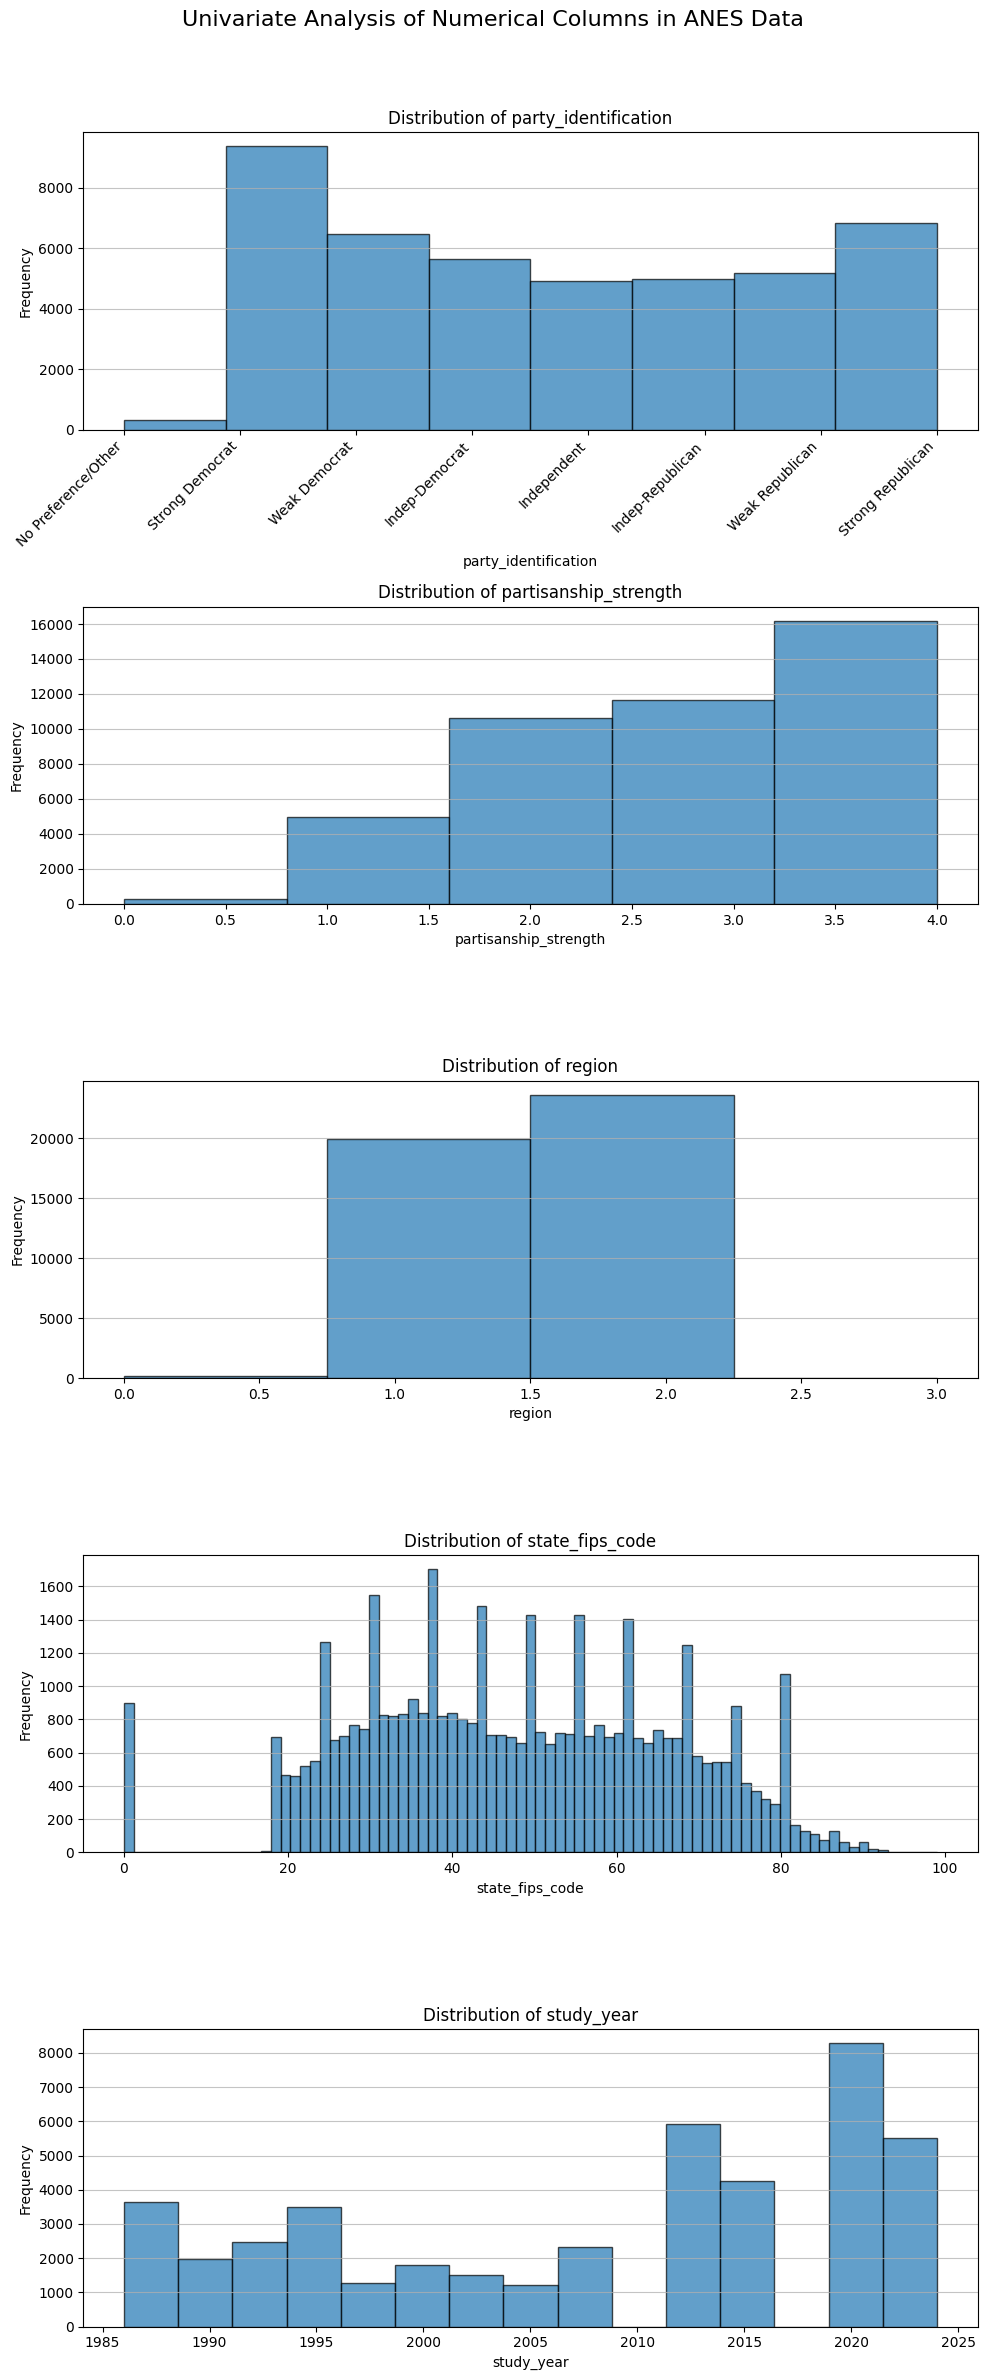

In [ ]:
# @title
import matplotlib.pyplot as plt
import pandas as pd

# Get numerical columns
numerical_cols = DATA_DF.select_dtypes(include=['number']).columns

# Set up the plotting environment
num_plots = len(numerical_cols)
fig, axes = plt.subplots(num_plots, 1, figsize=(10, 5 * num_plots))
fig.suptitle('Univariate Analysis of Numerical Columns in ANES Data', fontsize=16)

# Ensure axes is an array even for a single subplot
if num_plots == 1:
    axes = [axes]

# Define the mapping for 'party_identification'
party_id_labels = {
    0: 'No Preference/Other',
    1: 'Strong Democrat',
    2: 'Weak Democrat',
    3: 'Indep-Democrat',
    4: 'Independent',
    5: 'Indep-Republican',
    6: 'Weak Republican',
    7: 'Strong Republican'
}

# Plot histograms and print statistics for each numerical column
for i, col in enumerate(numerical_cols):
    ax = axes[i]

    # Calculate and print mean and standard deviation
    mean_val = DATA_DF[col].mean()
    std_val = DATA_DF[col].std()
    print(f"--- {col} ---")
    print(f"Mean: {mean_val:.2f}")
    print(f"Standard Deviation: {std_val:.2f}\n")

    # Plot histogram
    ax.hist(DATA_DF[col], bins=DATA_DF[col].nunique(), edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.75)

    # Apply custom labels and rotation for 'party_identification'
    if col == 'party_identification':
        # Get unique integer values from the data that are present in the labels map
        unique_values = sorted([val for val in DATA_DF[col].unique() if val in party_id_labels])
        # Get corresponding labels
        labels = [party_id_labels[val] for val in unique_values]

        ax.set_xticks(unique_values)
        ax.set_xticklabels(labels, rotation=45, ha='right') # Rotate labels

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap
plt.show()

**Prompt:** Refine histogram by state so that state names appear at an angle. Eliminate all entries where there is no state name associated with the FIPS.

## Result

# What we learned

* Need to be specific about the requests.
* Can revert to the prior version of code if we don't like the changes.



# Partisanship by state

We want to see how each state leans Democratic or Republican according to the ANES data and the variables we are using. A great presentation of this is to color states by their leaning. This means creating a map of the united states and controlling the colors of individual states.

##***SKILL: Think about your desired solution, not the programming details.***

## Interactions

**Prompt for partisanship by state**

Use DATA_DF to plot a map of the US with a color code for percent demographic. This should be a heatmap with blue for democratic becoming increasingly red as the percentage of replicans increase. An equal percentage of both should be purple.

In [ ]:
# @title
import pandas as pd
import numpy as np
import folium
import us
import json
import requests

# URL for a GeoJSON file of US states (a common source)
US_STATES_GEOJSON_URL = 'https://raw.githubusercontent.com/python-visualization/folium-example-data/main/us_states.json'
# Fetch the GeoJSON data
response = requests.get(US_STATES_GEOJSON_URL)
US_STATES_GEOJSON = json.loads(response.text)

def categorize_party(party_id):
    if party_id in [1, 2, 3]:
        return 'Democrat'
    elif party_id in [5, 6, 7]:
        return 'Republican'
    elif party_id in [0, 4]:
        return 'Other/Independent'
    else:
        return np.nan

def plot_partisan_map(input_df, us_states_geojson=US_STATES_GEOJSON, start_year=None, end_year=None, map_width=700, map_height=400):
    """
    Constructs a choropleth map of US states showing partisan leanings.

    Args:
        input_df (pd.DataFrame): The input DataFrame structured like DATA_DF,
                                 containing 'party_identification', 'state_fips_code',
                                 and 'study_year'.
        us_states_geojson (dict): GeoJSON data for US states.
        start_year (int, optional): The starting year for filtering the data.
        end_year (int, optional): The ending year for filtering the data.
        map_width (int, optional): The width of the generated Folium map in pixels. Defaults to 700.
        map_height (int, optional): The height of the generated Folium map in pixels. Defaults to 400.

    Returns:
        folium.Map: An interactive Folium map displaying partisan leanings.
    """

    filtered_df = input_df.copy()

    # Filter by year if start_year or end_year are provided
    if start_year is not None:
        filtered_df = filtered_df[filtered_df['study_year'] >= start_year]
    if end_year is not None:
        filtered_df = filtered_df[filtered_df['study_year'] <= end_year]

    # Apply partisan categorization
    filtered_df['partisan_category'] = filtered_df['party_identification'].apply(categorize_party)

    # Calculate partisan proportions per state
    state_partisan_counts = filtered_df.groupby(['state_fips_code', 'partisan_category']).size().unstack(fill_value=0)
    state_partisan_proportions = state_partisan_counts.div(state_partisan_counts.sum(axis=1), axis=0)

    # Ensure 'Republican' and 'Democrat' columns exist, filling with 0 if not present
    for party_col in ['Republican', 'Democrat']:
        if party_col not in state_partisan_proportions.columns:
            state_partisan_proportions[party_col] = 0

    # Calculate partisan lean
    state_partisan_proportions['partisan_lean'] = state_partisan_proportions['Republican'] - state_partisan_proportions['Democrat']

    # Prepare data for Folium (indexing and FIPS/abbr mapping)
    state_partisan_proportions_indexed = state_partisan_proportions.reset_index()
    state_partisan_proportions_indexed['state_fips_code'] = state_partisan_proportions_indexed['state_fips_code'].astype(int).astype(str).str.zfill(2) # Ensure 2-digit FIPS codes

    # Create a mapping from FIPS codes to state abbreviations
    fips_to_abbr = {str(state.fips): state.abbr for state in us.states.STATES + us.states.TERRITORIES}

    # Add a 'state_abbr' column for matching with geojson 'feature.id'
    state_partisan_proportions_indexed['state_abbr'] = state_partisan_proportions_indexed['state_fips_code'].map(fips_to_abbr)

    # Filter out rows where state_abbr is NaN (i.e., FIPS code did not map to a recognized state abbreviation)
    state_partisan_proportions_indexed.dropna(subset=['state_abbr'], inplace=True)

    # Create a Folium map centered on the US, disabling pan and zoom
    m = folium.Map(location=[39.8283, -98.5795], zoom_start=3, scrollWheelZoom=False, dragging=False, width=map_width, height=map_height)

    # Create a linear colormap from blue to purple to red
    blue_to_red = folium.LinearColormap(['blue', 'purple', 'red'], vmin=-1.0, vmax=1.0)

    # Add the choropleth layer to the map
    folium.Choropleth(
        geo_data=us_states_geojson,
        name='Partisan Lean',
        data=state_partisan_proportions_indexed,
        columns=['state_abbr', 'partisan_lean'], # Use 'state_abbr' for matching with 'feature.id'
        key_on='feature.id', # Now this will match 'state_abbr'
        fill_opacity=0.7,
        line_opacity=0.2,
        fill_color='RdBu',
        legend_name='Partisan Lean (Republican - Democrat)',
        bins=[-1, -0.5, -0.25, 0, 0.25, 0.5, 1], # Custom bins to highlight different leanings
        cmap=blue_to_red # This colormap maps negative lean to blue, positive to red
    ).add_to(m)

    # Add a layer control to the map
    folium.LayerControl().add_to(m)

    return m, state_partisan_proportions_indexed

# Example usage of the function:
# Assuming US_STATES_GEOJSON is already loaded from the previous steps
# US_STATES_GEOJSON = ... (make sure this variable is available)

# Plot the map for the entire dataset
# map_full_data = plot_partisan_map(DATA_DF)
# display(map_full_data)

# Example: Plot the map for data from 1980 onwards
# map_1980_onwards = plot_partisan_map(DATA_DF, start_year=1980)
# display(map_1980_onwards)

# Example:
map, indexed = plot_partisan_map(DATA_DF, start_year=2000,
                        end_year=2030)
display(map)

## Result

# Partisanship by state over time

We want to show multiple maps of the united states over time to examine how state colors have changed.

## Interactions

**Prompt: Partisanship over time**

Write code to display a sequence of partisanship plots by decade beginning with 1960 through 2020.

**Prompt: Modify partisanship plots**

Create a grid of plots in sequence. Only display the U.S. Disable pan and zoom. Use plot_partisanship_map, but modify it as needed.

**Prompt: Detailed code instruction**
Write a loop that calls plot_partisan_map over the different decades where data are available.

## Hand code

In [ ]:
import pandas as pd
import numpy as np
import folium
import us

def categorize_party(party_id):
    if party_id in [1, 2, 3]:
        return 'Democrat'
    elif party_id in [5, 6, 7]:
        return 'Republican'
    elif party_id in [0, 4]:
        return 'Other/Independent'
    else:
        return np.nan

def plot_partisan_map(input_df, us_states_geojson=US_STATES_GEOJSON, start_year=None,
        end_year=None, map_width=700, map_height=400, is_colorbar:bool=True):
    """
    Constructs a choropleth map of US states showing partisan leanings.

    Args:
        input_df (pd.DataFrame): The input DataFrame structured like DATA_DF,
                                 containing 'party_identification', 'state_fips_code',
                                 and 'study_year'.
        us_states_geojson (dict): GeoJSON data for US states.
        start_year (int, optional): The starting year for filtering the data.
        end_year (int, optional): The ending year for filtering the data.
        map_width (int, optional): The width of the generated Folium map in pixels. Defaults to 700.
        map_height (int, optional): The height of the generated Folium map in pixels. Defaults to 400.
        is_colorbar (bool, optional): Whether to include a colorbar. Defaults to True.

    Returns:
        folium.Map: An interactive Folium map displaying partisan leanings.
    """

    filtered_df = input_df.copy()

    # Filter by year if start_year or end_year are provided
    if start_year is not None:
        filtered_df = filtered_df[filtered_df['study_year'] >= start_year]
    if end_year is not None:
        filtered_df = filtered_df[filtered_df['study_year'] <= end_year]

    # Apply partisan categorization
    filtered_df['partisan_category'] = filtered_df['party_identification'].apply(categorize_party)

    # Calculate partisan proportions per state
    state_partisan_counts = filtered_df.groupby(['state_fips_code', 'partisan_category']).size().unstack(fill_value=0)
    state_partisan_proportions = state_partisan_counts.div(state_partisan_counts.sum(axis=1), axis=0)

    # Ensure 'Republican' and 'Democrat' columns exist, filling with 0 if not present
    for party_col in ['Republican', 'Democrat']:
        if party_col not in state_partisan_proportions.columns:
            state_partisan_proportions[party_col] = 0

    # Calculate partisan lean
    state_partisan_proportions['partisan_lean'] = state_partisan_proportions['Republican'] - state_partisan_proportions['Democrat']

    # Prepare data for Folium (indexing and FIPS/abbr mapping)
    state_partisan_proportions_indexed = state_partisan_proportions.reset_index()
    state_partisan_proportions_indexed['state_fips_code'] = state_partisan_proportions_indexed['state_fips_code'].astype(int).astype(str).str.zfill(2) # Ensure 2-digit FIPS codes

    # Create a mapping from FIPS codes to state abbreviations
    fips_to_abbr = {str(state.fips): state.abbr for state in us.states.STATES + us.states.TERRITORIES}

    # Add a 'state_abbr' column for matching with geojson 'feature.id'
    state_partisan_proportions_indexed['state_abbr'] = state_partisan_proportions_indexed['state_fips_code'].map(fips_to_abbr)

    # Filter out rows where state_abbr is NaN (i.e., FIPS code did not map to a recognized state abbreviation)
    state_partisan_proportions_indexed.dropna(subset=['state_abbr'], inplace=True)

    # Create a Folium map centered on the US, disabling pan and zoom
    m = folium.Map(location=[39.8283, -98.5795], zoom_start=3, scrollWheelZoom=False, dragging=False, width=map_width, height=map_height)

    # Create a linear colormap from blue to purple to red
    blue_to_red = folium.LinearColormap(['blue', 'purple', 'red'], vmin=-1.0, vmax=1.0)

    # Add the choropleth layer to the map
    choloropath = folium.Choropleth(
        geo_data=us_states_geojson,
        name='Partisan Lean',
        data=state_partisan_proportions_indexed,
        columns=['state_abbr', 'partisan_lean'], # Use 'state_abbr' for matching with 'feature.id'
        key_on='feature.id', # Now this will match 'state_abbr'
        fill_opacity=0.7,
        line_opacity=0.2,
        fill_color='RdBu',
        legend_name='Partisan Lean (Republican - Democrat)',
        bins=[-1, -0.5, -0.25, 0, 0.25, 0.5, 1], # Custom bins to highlight different leanings
        cmap=blue_to_red, # This colormap maps negative lean to blue, positive to red
        show_colorbar=False # Explicitly set to False to hide the colorbar
    ).add_to(m)

    # Remove the colorbar child from the choropleth
    if not is_colorbar:
        for child in list(choloropath._children):
            if child.startswith('color_map'):
                del choloropath._children[child]

    # Add a layer control to the map
    folium.LayerControl().add_to(m)

    return m, state_partisan_proportions_indexed

# Example usage of the function:
# Assuming us_states_geojson is already loaded from the previous steps
# us_states_geojson = ... (make sure this variable is available)

# Plot the map for the entire dataset
# map_full_data = plot_partisan_map(DATA_DF)
# display(map_full_data)

# Example: Plot the map for data from 1980 onwards
# map_1980_onwards = plot_partisan_map(DATA_DF, us_states_geojson, start_year=1980)
# display(map_1980_onwards)

# Example:
map, indexed = plot_partisan_map(DATA_DF, start_year=2000,
                        end_year=2030)
display(map)

In [ ]:
# Define the decades for which to generate maps
decades = [
    (1960, 1969),
    (1970, 1979),
    (1980, 1989),
    (1990, 1999),
    (2000, 2009),
    (2010, 2019),
    (2020, 2029)
]

print("Decades defined successfully.")

Decades defined successfully.


In [ ]:
from IPython.display import HTML

# List to hold HTML representations of each map
maps_html = []

for i, (start_year, end_year) in enumerate(decades):
    # Generate the map for the current decade
    map_decade, _ = plot_partisan_map(DATA_DF, start_year=start_year,
            end_year=end_year, map_width=500, map_height=200, is_colorbar=(i==0))

    # Get the HTML representation of the map
    map_html = map_decade._repr_html_()

    # Add a title and the map HTML to the list
    maps_html.append(f"<div style='margin-bottom: 10px;'><h3>Partisan Lean Map for the Decade: {start_year}-{end_year}</h3>{map_html}</div>")

# Combine all map HTMLs into a single string
# Using a flex container to potentially arrange them more compactly, or just stacked
combined_html = "<div style='display: flex; flex-direction: column; gap: 5px;'>" + "".join(maps_html) + "</div>"

# Display the combined HTML
display(HTML(combined_html))

## What we learned

# Tips & Tricks

**Objectives**

* Create correctly running code
* Create a notebook that can be re-run
* Create a "trail" of what you did

**Good Practices**

* Delete unneeded code
* Clearly indicate global variables by naming them in CAPITAL letters
* Write your prompt in the notebook with a title. Have gemini run the prompt by referring to the title.
* Have a clear idea of what you want BEFORE you prompt, and then check the result produced.
* If Gemini is not correctly modifying a function, copy the function into another LLM (e.g., Claude) and ask it to fix the code.
* Change the names of global variables to be meaningful for your purposes. Use Gemini to make sure that the name is changed throughout your notebook.
* Have Gemini create functions and write tests for the functions inside the cell.

# Making a sharable notebook

A notebook is sharable if others can run it and get the same results that you did.

The most common example of "others" is YOU several months later.

##***SKILL: Restart the kernel and run the notebook to verify that it is sharable by others.***

# Review of learning objectives

1. Students will be able to write prompts to list the descriptions and scales of variables used in the analysis.
1. Students will be able to compose LLM prompts for:
    1. creating a pandas DataFrame containing variables of interest with descriptive column names for the variables;
    1. constructing univariate statistics for categorical data;
    1. constructing heatmaps of the US (choropleths).
1. Students can find known results to assess the correctness of the results of code execution.
1.  Students will be able to construct notebooks that run correctly when shared with others.
